In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# Importações do Scikit-learn e Statsmodels
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.multioutput import MultiOutputRegressor, RegressorChain

from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier, Fourier

# --- 1. PREPARAÇÃO INICIAL ---

# Carregar e preparar os dados (seu código)
df = pd.read_csv('../teste/dados_sabesp_cantareira_historico.csv', sep=';', parse_dates=['Data'], dayfirst=True, decimal=',')
df['Data'] = pd.to_datetime(df['Data'])
df = df[['Data', 'Volume Útil Armazenado (%)']]
df = df[df['Data'] > '2016-04-01']
df.set_index('Data', inplace=True)
df = df.sort_index()
df = df.asfreq('D') # Garantir frequência diária, preenchendo falhas se houver
df[df.columns[0]] = df[df.columns[0]].interpolate(method='time')



In [15]:

# --- CONSTANTES GLOBAIS ---
TARGET = 'Volume Útil Armazenado (%)'
FORECAST_HORIZON = 90
LAG = 15
N_SPLITS = 10 # Número de janelas de validação (folds)

# --- 2. SETUP DO LOOP DE VALIDAÇÃO CRUZADA ---

# TimeSeriesSplit garante que os dados de treino sempre vêm antes dos de teste.
tscv = TimeSeriesSplit(
    n_splits=N_SPLITS,
    test_size=FORECAST_HORIZON,
    gap=0 # Sem gap entre treino e teste
)

# Listas para armazenar os resultados de cada fold
all_preds_lr = []
all_preds_hybrid = []
all_y_test = []

def make_multistep_target(ts, steps):
    """
    Transforma uma série temporal 1D em um DataFrame 2D para previsão multi-step.
    """
    return pd.concat(
        {f'y_step_{i + 1}': ts.shift(-i) for i in range(steps)},
        axis=1
    ).dropna()


Iniciando Walk-Forward Validation com 10 splits...
Fold 1/10
  - Período de Treino: 2016-04-02 a 2023-04-21
  - Período de Teste:  2023-04-22 a 2023-07-20

--- RESULTADOS GLOBAIS (Out-of-Sample) ---

Modelo 1: Regressão Linear
  - MAE: 13.0442
  - RMSE: 13.5432

Modelo 2: Híbrido (LR Trend + XGBoost DirRec Residuals)
  - MAE: 26.3737
  - RMSE: 26.4481


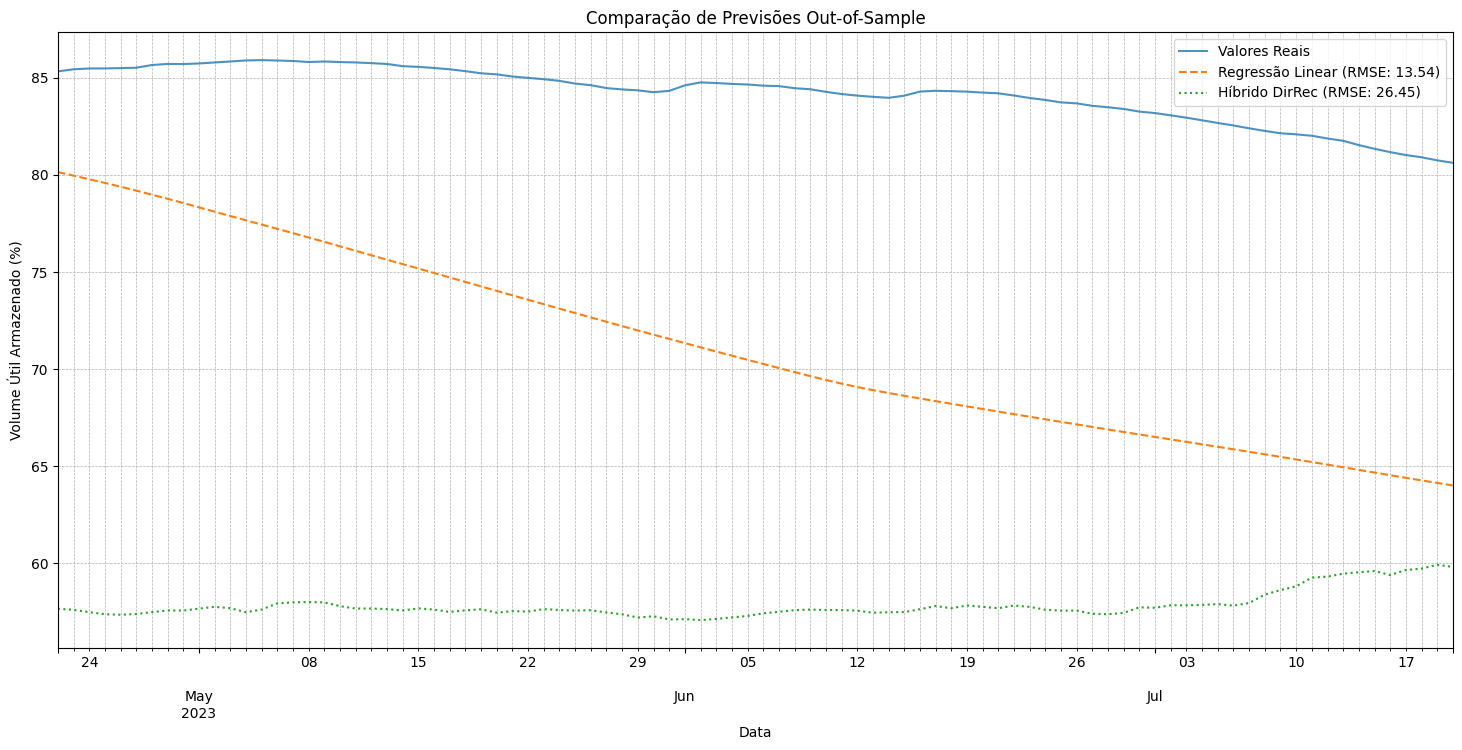

Fold 2/10
  - Período de Treino: 2016-04-02 a 2023-07-20
  - Período de Teste:  2023-07-21 a 2023-10-18

--- RESULTADOS GLOBAIS (Out-of-Sample) ---

Modelo 1: Regressão Linear
  - MAE: 1.4961
  - RMSE: 2.7039

Modelo 2: Híbrido (LR Trend + XGBoost DirRec Residuals)
  - MAE: 8.9472
  - RMSE: 9.8787


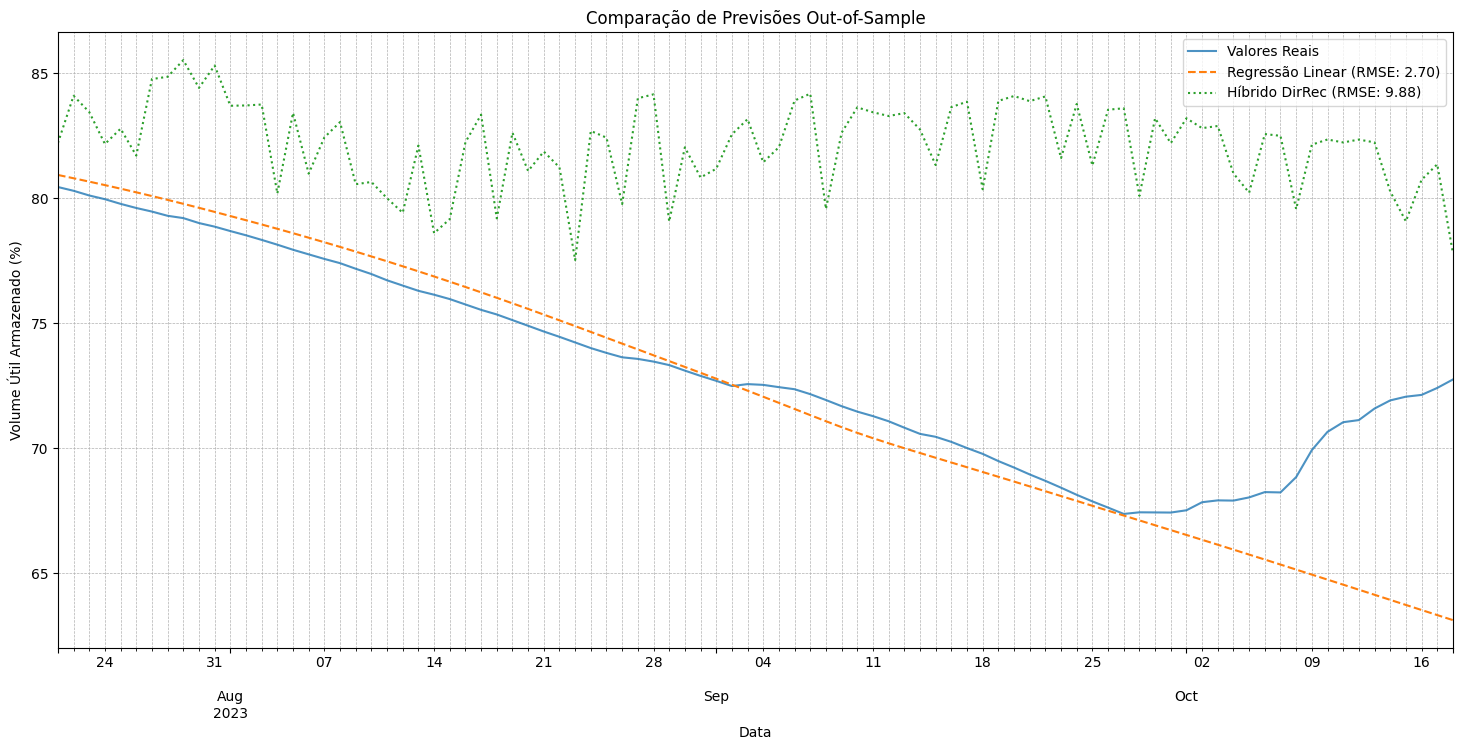

Fold 3/10
  - Período de Treino: 2016-04-02 a 2023-10-18
  - Período de Teste:  2023-10-19 a 2024-01-16

--- RESULTADOS GLOBAIS (Out-of-Sample) ---

Modelo 1: Regressão Linear
  - MAE: 12.3262
  - RMSE: 12.5709

Modelo 2: Híbrido (LR Trend + XGBoost DirRec Residuals)
  - MAE: 8.6461
  - RMSE: 8.8309


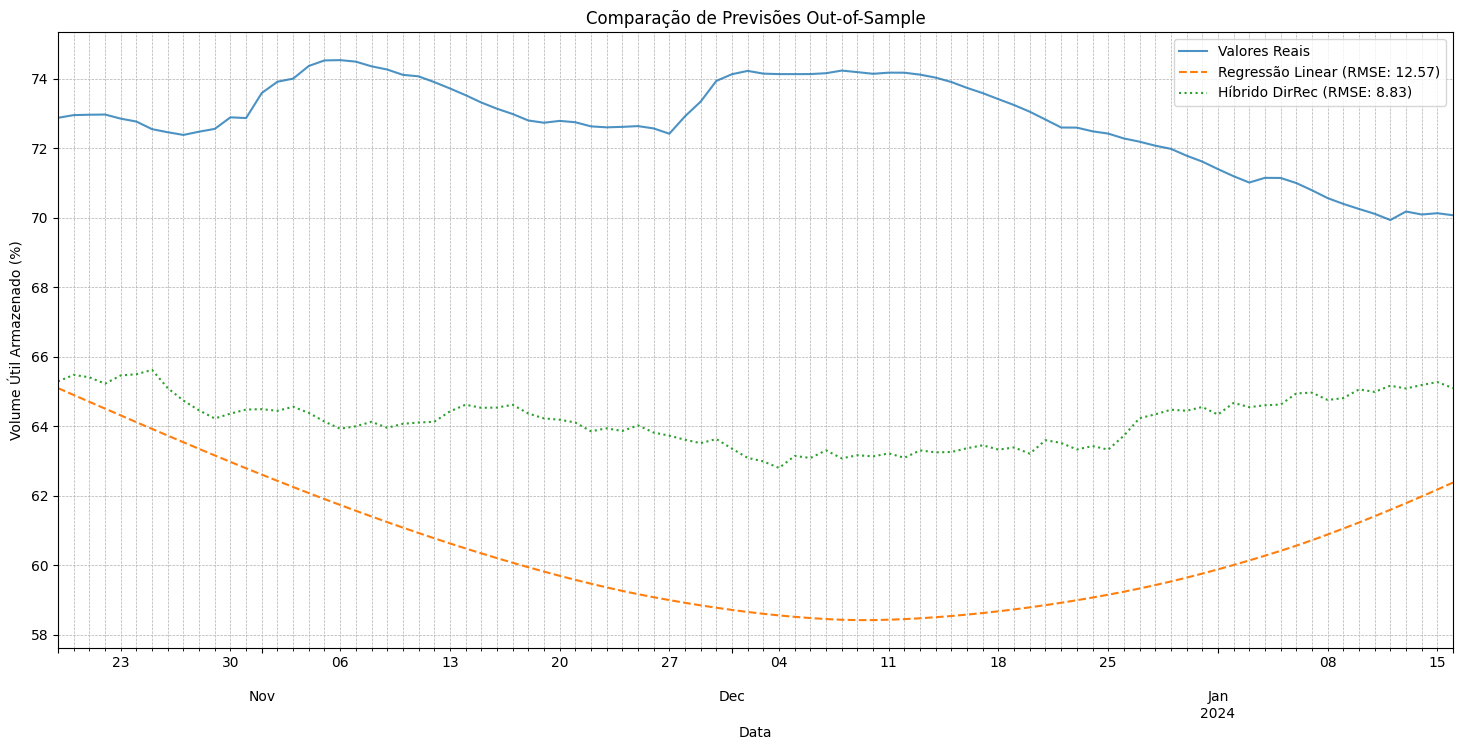

Fold 4/10
  - Período de Treino: 2016-04-02 a 2024-01-16
  - Período de Teste:  2024-01-17 a 2024-04-15

--- RESULTADOS GLOBAIS (Out-of-Sample) ---

Modelo 1: Regressão Linear
  - MAE: 6.5303
  - RMSE: 6.8280

Modelo 2: Híbrido (LR Trend + XGBoost DirRec Residuals)
  - MAE: 3.9516
  - RMSE: 4.5036


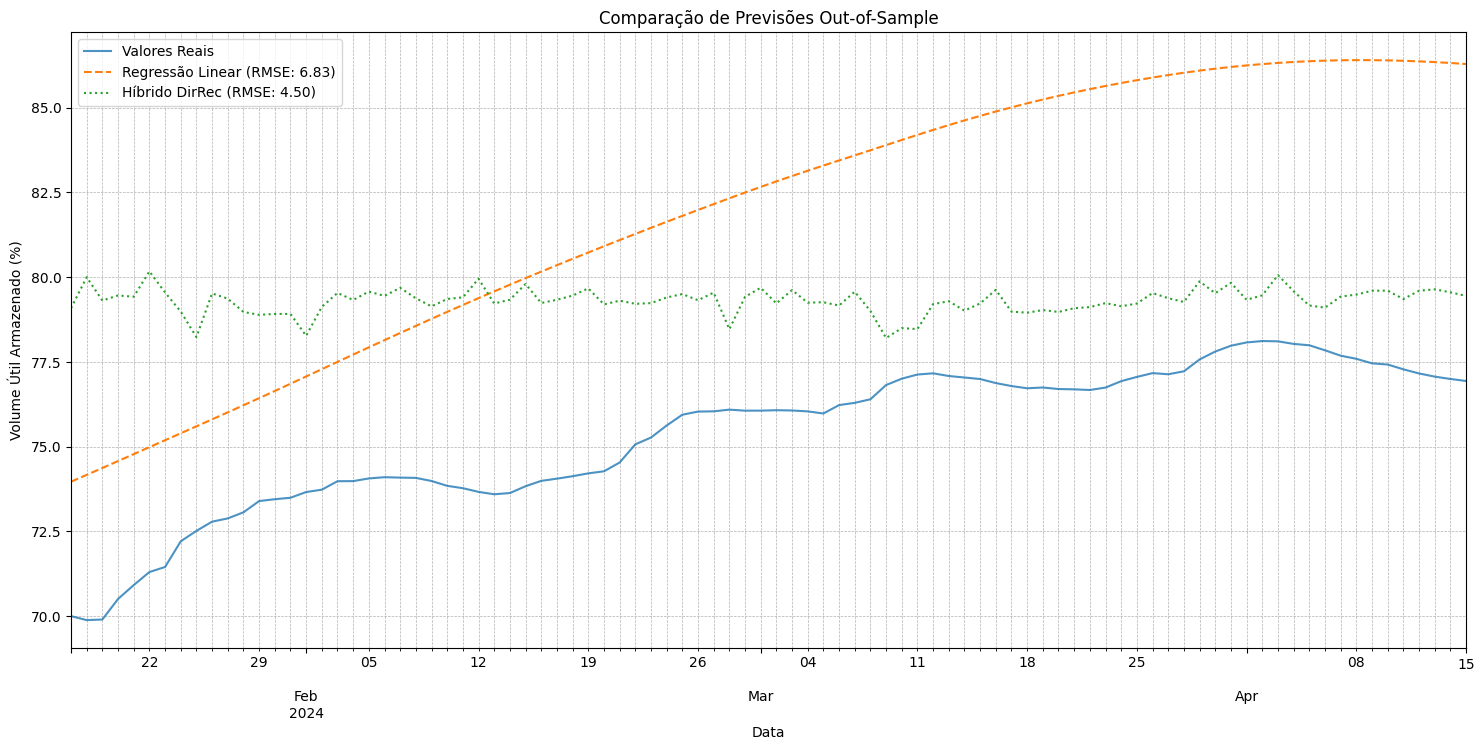

Fold 5/10
  - Período de Treino: 2016-04-02 a 2024-04-15
  - Período de Teste:  2024-04-16 a 2024-07-14

--- RESULTADOS GLOBAIS (Out-of-Sample) ---

Modelo 1: Regressão Linear
  - MAE: 4.8083
  - RMSE: 4.9327

Modelo 2: Híbrido (LR Trend + XGBoost DirRec Residuals)
  - MAE: 5.9597
  - RMSE: 6.5215


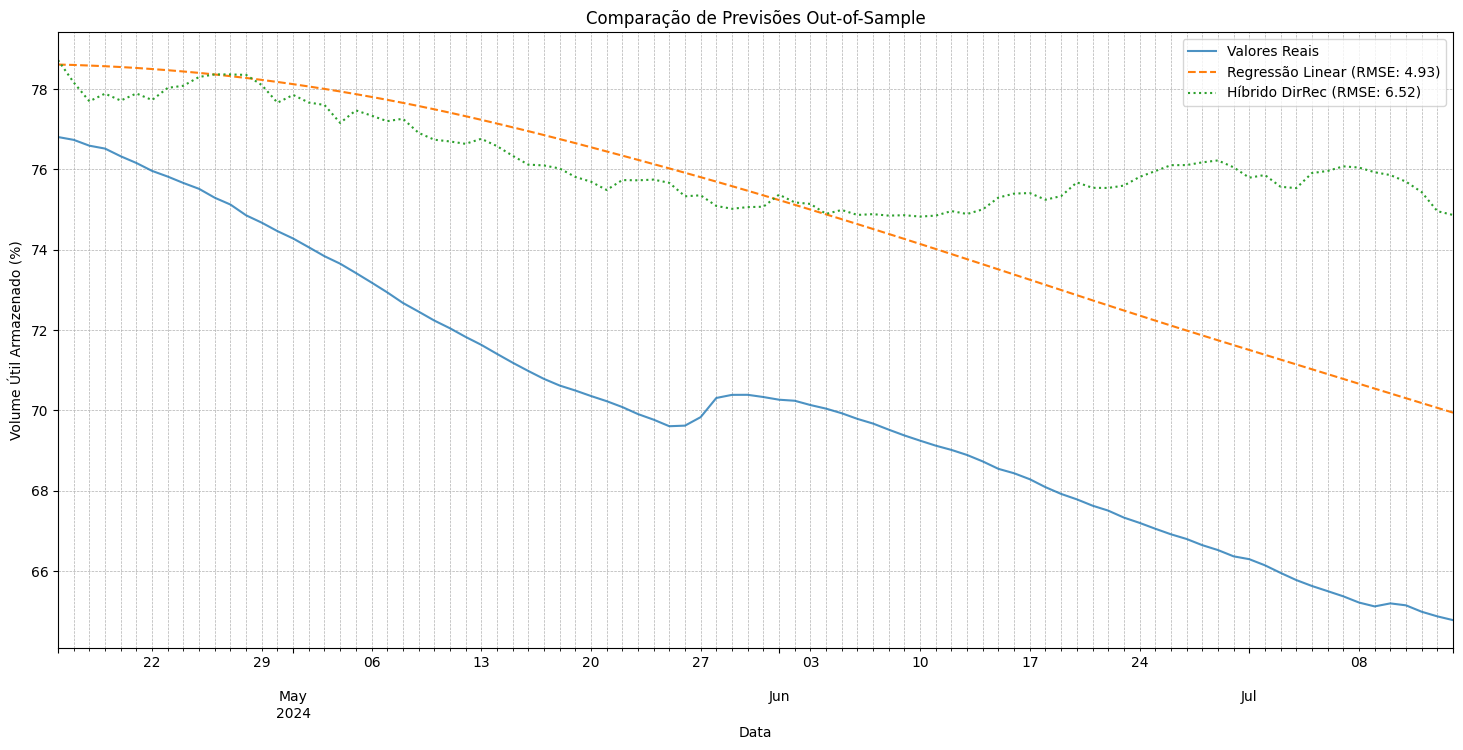

Fold 6/10
  - Período de Treino: 2016-04-02 a 2024-07-14
  - Período de Teste:  2024-07-15 a 2024-10-12

--- RESULTADOS GLOBAIS (Out-of-Sample) ---

Modelo 1: Regressão Linear
  - MAE: 3.3253
  - RMSE: 3.8896

Modelo 2: Híbrido (LR Trend + XGBoost DirRec Residuals)
  - MAE: 13.1358
  - RMSE: 14.6509


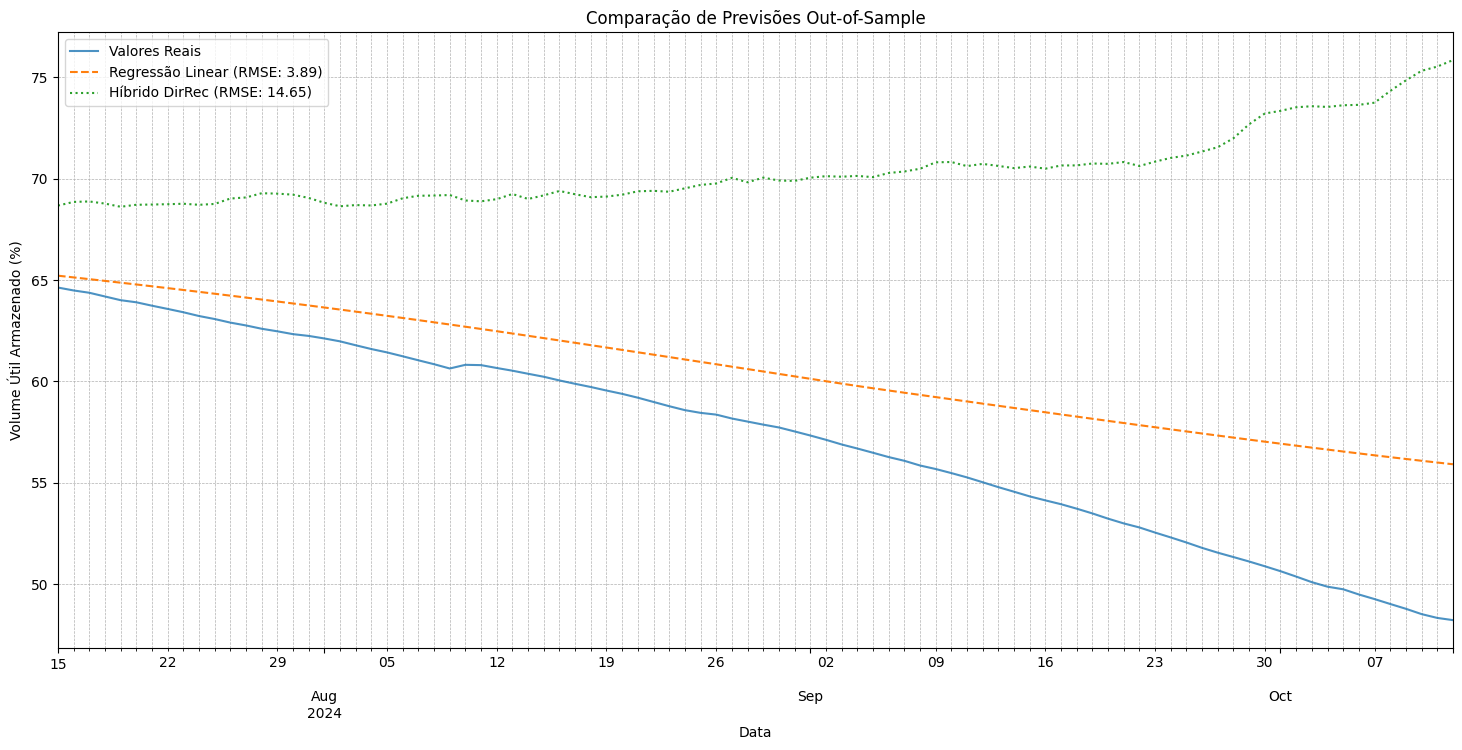

Fold 7/10
  - Período de Treino: 2016-04-02 a 2024-10-12
  - Período de Teste:  2024-10-13 a 2025-01-10

--- RESULTADOS GLOBAIS (Out-of-Sample) ---

Modelo 1: Regressão Linear
  - MAE: 3.3238
  - RMSE: 3.7516

Modelo 2: Híbrido (LR Trend + XGBoost DirRec Residuals)
  - MAE: 9.8368
  - RMSE: 9.9892


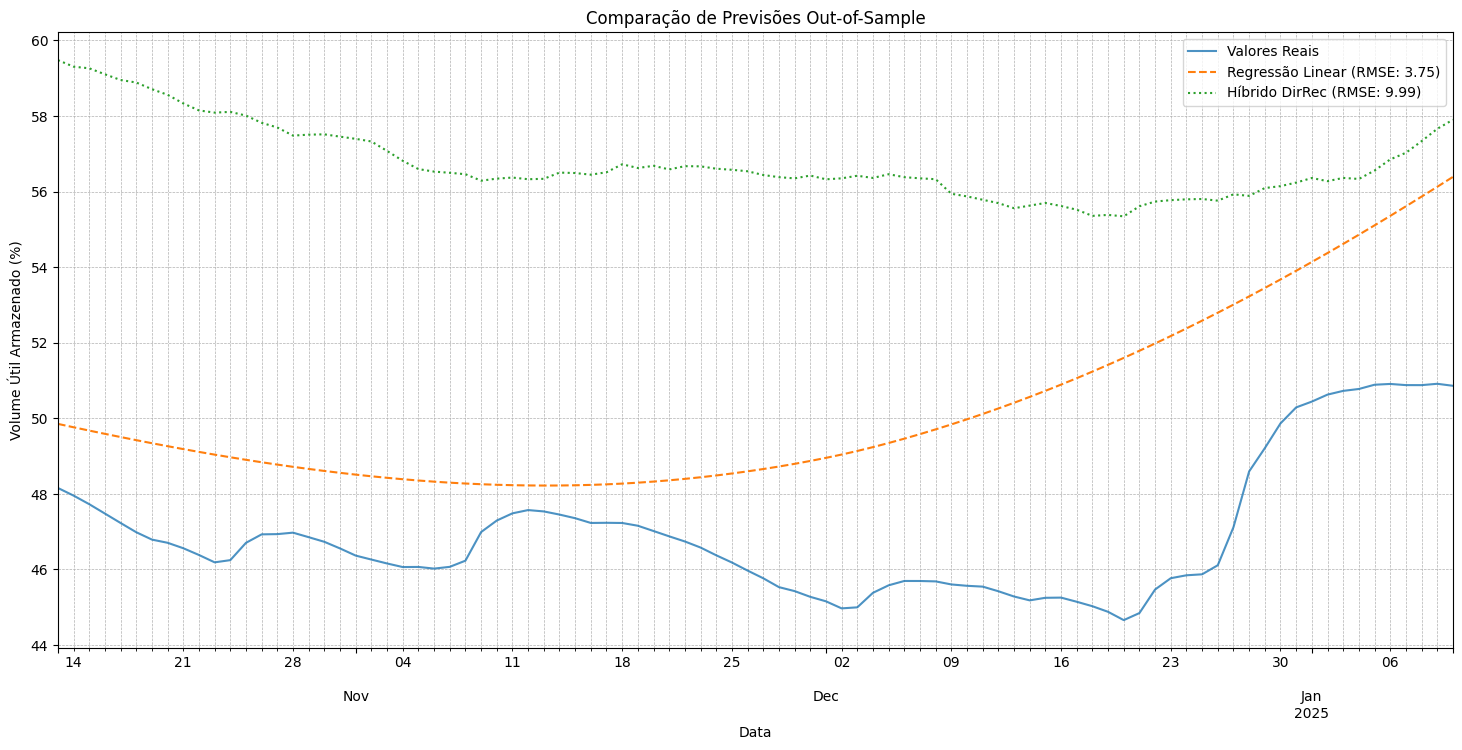

Fold 8/10
  - Período de Treino: 2016-04-02 a 2025-01-10
  - Período de Teste:  2025-01-11 a 2025-04-10

--- RESULTADOS GLOBAIS (Out-of-Sample) ---

Modelo 1: Regressão Linear
  - MAE: 5.4772
  - RMSE: 6.6163

Modelo 2: Híbrido (LR Trend + XGBoost DirRec Residuals)
  - MAE: 2.9921
  - RMSE: 3.5482


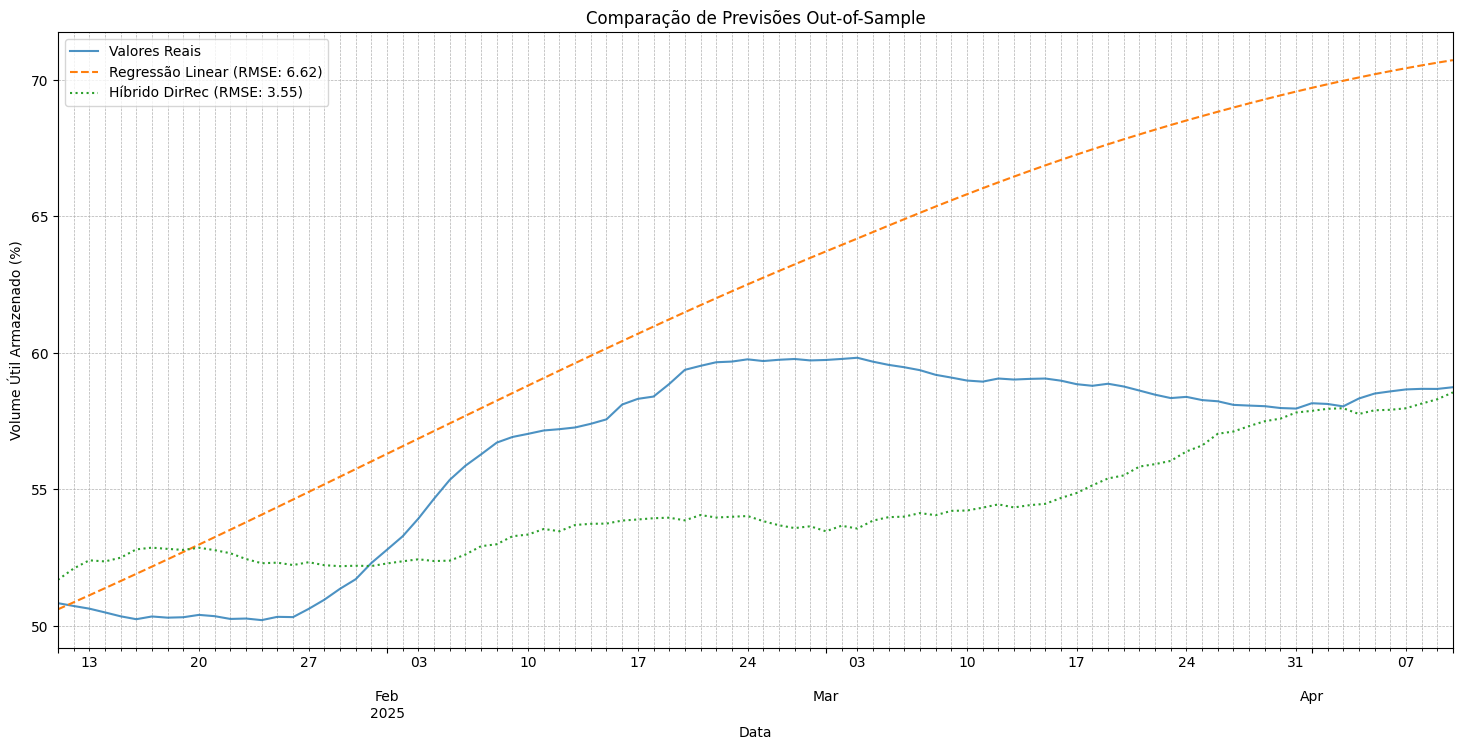

Fold 9/10
  - Período de Treino: 2016-04-02 a 2025-04-10
  - Período de Teste:  2025-04-11 a 2025-07-09

--- RESULTADOS GLOBAIS (Out-of-Sample) ---

Modelo 1: Regressão Linear
  - MAE: 6.2734
  - RMSE: 7.0989

Modelo 2: Híbrido (LR Trend + XGBoost DirRec Residuals)
  - MAE: 13.6323
  - RMSE: 14.1488


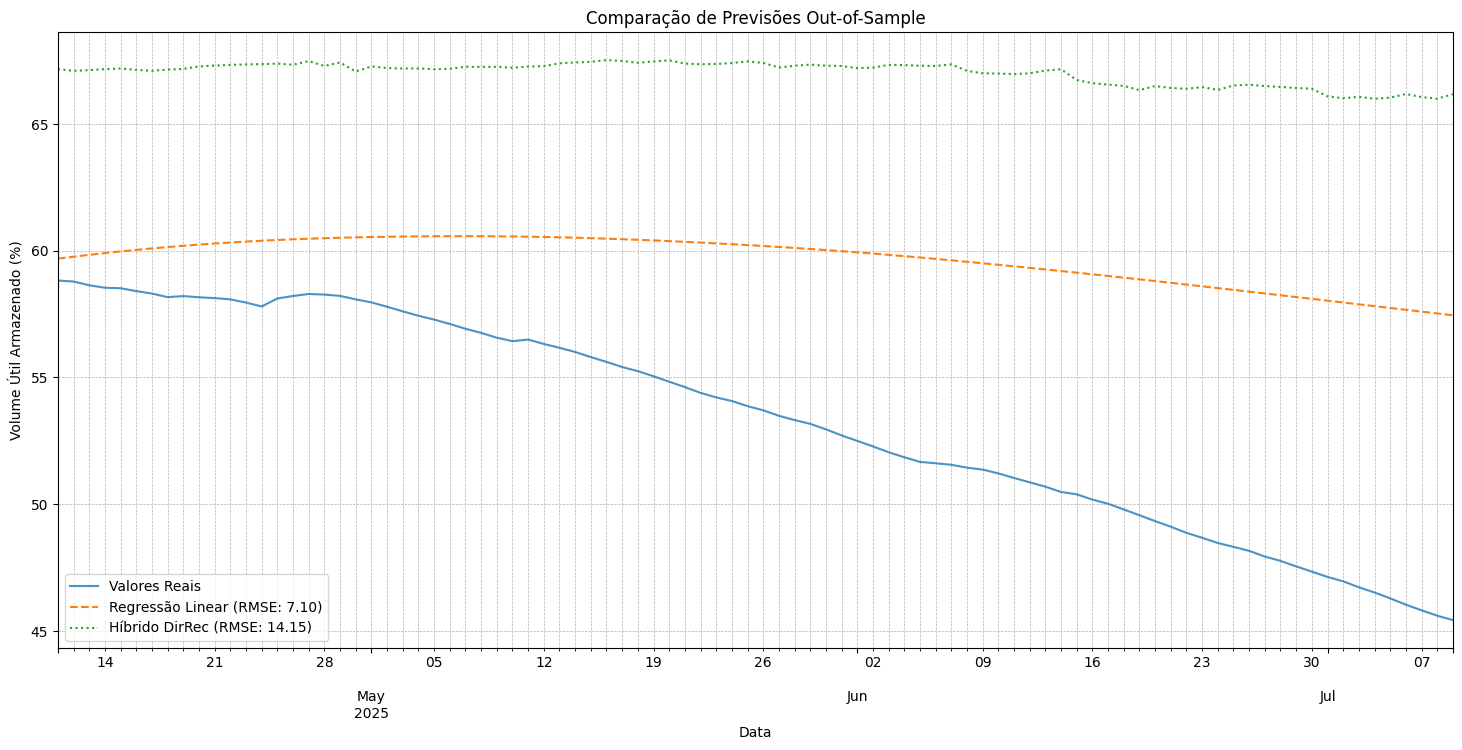

Fold 10/10
  - Período de Treino: 2016-04-02 a 2025-07-09
  - Período de Teste:  2025-07-10 a 2025-10-07

--- RESULTADOS GLOBAIS (Out-of-Sample) ---

Modelo 1: Regressão Linear
  - MAE: 6.6214
  - RMSE: 7.1210

Modelo 2: Híbrido (LR Trend + XGBoost DirRec Residuals)
  - MAE: 13.1421
  - RMSE: 13.5342


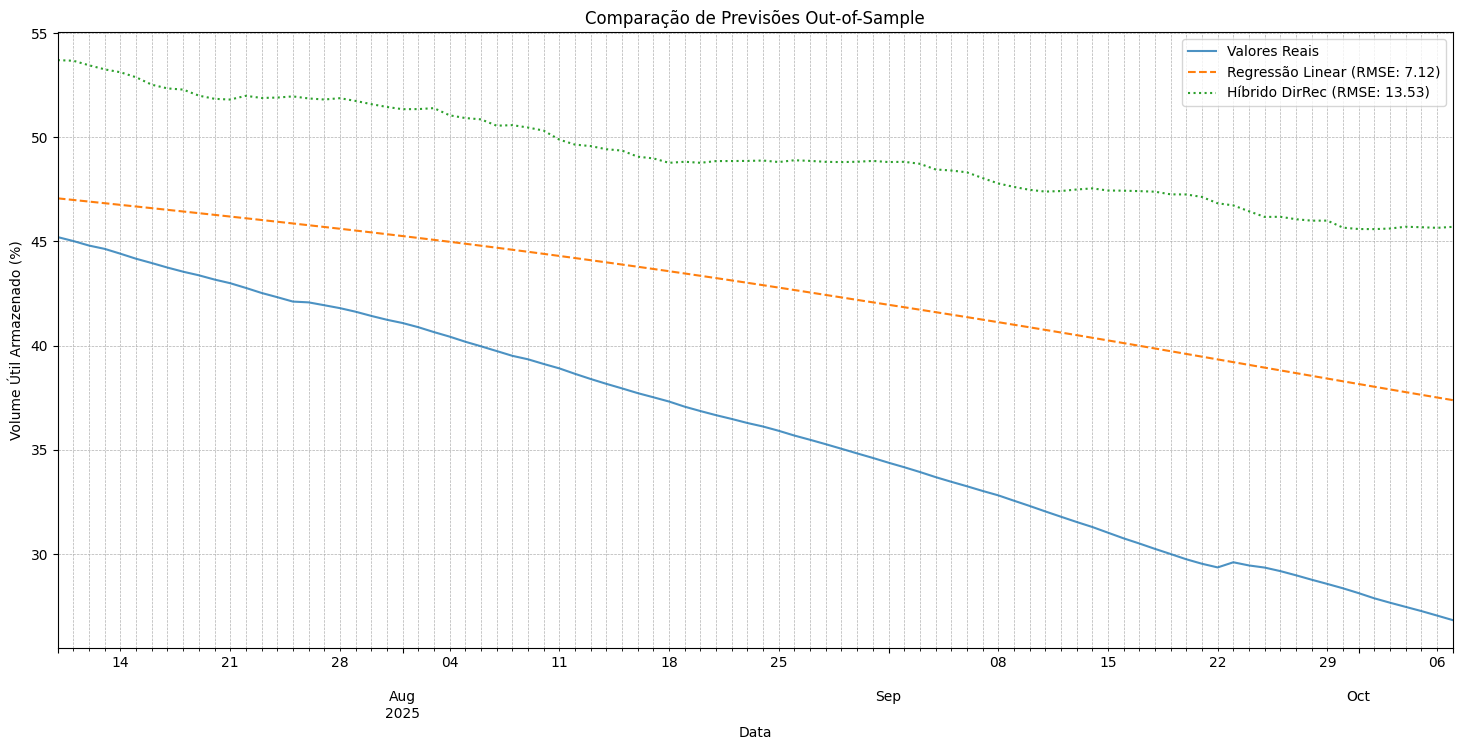

Validação finalizada.

--- RESULTADOS GLOBAIS (Out-of-Sample) ---

Modelo 1: Regressão Linear
  - MAE: 6.6604
  - RMSE: 8.1214

Modelo 2: Híbrido (LR Trend + XGBoost DirRec Residuals)
  - MAE: 10.8814
  - RMSE: 13.2160


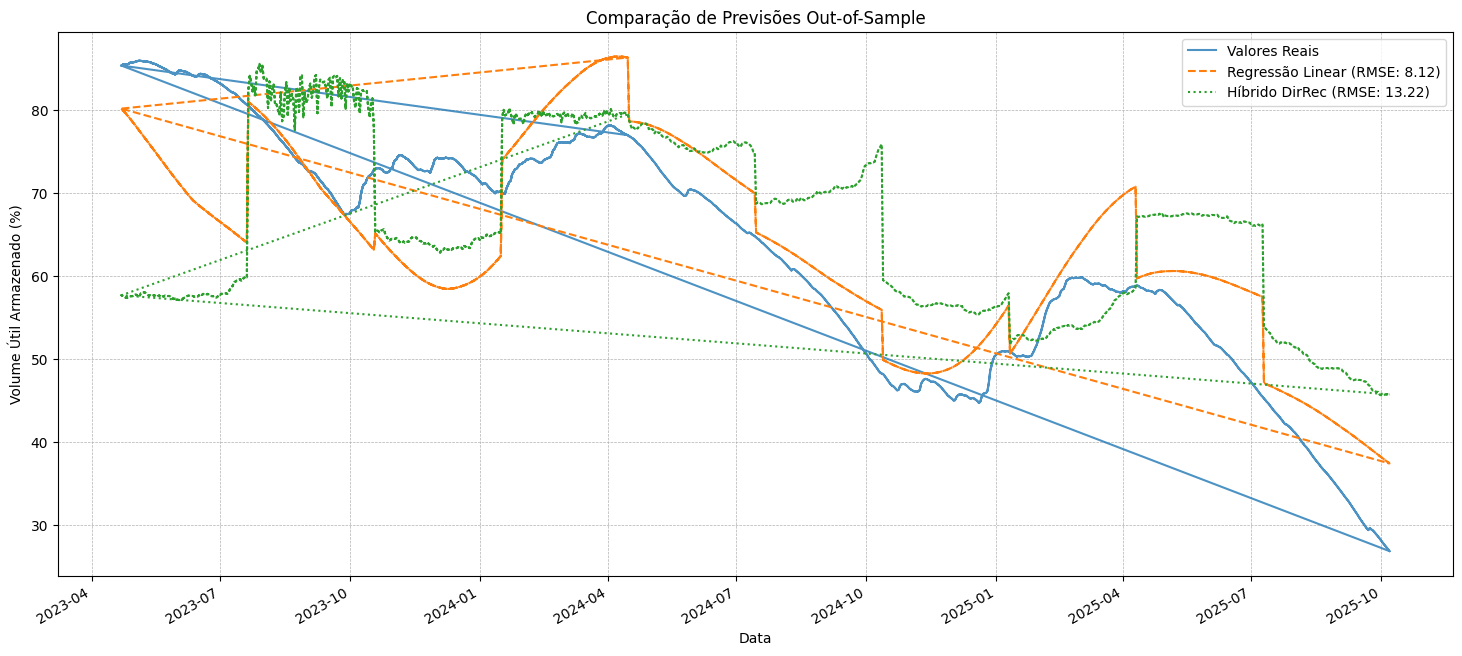

'mae_lr = mean_absolute_error(final_y_test, final_preds_lr)\nrmse_lr = np.sqrt(mean_squared_error(final_y_test, final_preds_lr))\n\nmae_hybrid = mean_absolute_error(final_y_test, final_preds_hybrid)\nrmse_hybrid = np.sqrt(mean_squared_error(final_y_test, final_preds_hybrid))\n\nprint("\n--- RESULTADOS GLOBAIS (Out-of-Sample) ---")\nprint("\nModelo 1: Regressão Linear")\nprint(f"  - MAE: {mae_lr:.4f}")\nprint(f"  - RMSE: {rmse_lr:.4f}")\n\nprint("\nModelo 2: Híbrido (LR Trend + XGBoost DirRec Residuals)")\nprint(f"  - MAE: {mae_hybrid:.4f}")\nprint(f"  - RMSE: {rmse_hybrid:.4f}")\n\n# Plot final\nplt.figure(figsize=(18, 8))\nfinal_y_test.plot(label=\'Valores Reais\', alpha=0.8)\nfinal_preds_lr.plot(label=f\'Regressão Linear (RMSE: {rmse_lr:.2f})\', linestyle=\'--\')\nfinal_preds_hybrid.plot(label=f\'Híbrido DirRec (RMSE: {rmse_hybrid:.2f})\', linestyle=\':\')\nplt.title(\'Comparação de Previsões Out-of-Sample\')\nplt.ylabel(TARGET)\nplt.legend()\nplt.grid(True, which=\'both\', linestyle

In [24]:

print(f"Iniciando Walk-Forward Validation com {N_SPLITS} splits...")
print("="*50)

def previsao_grafico(y_true, y_pred, y_pred_hibrid):
    mae_lr = mean_absolute_error(y_true, y_pred)
    rmse_lr = np.sqrt(mean_squared_error(y_true, y_pred))

    mae_hybrid = mean_absolute_error(y_true, y_pred_hibrid)
    rmse_hybrid = np.sqrt(mean_squared_error(y_true, y_pred_hibrid))

    print("\n--- RESULTADOS GLOBAIS (Out-of-Sample) ---")
    print("\nModelo 1: Regressão Linear")
    print(f"  - MAE: {mae_lr:.4f}")
    print(f"  - RMSE: {rmse_lr:.4f}")

    print("\nModelo 2: Híbrido (LR Trend + XGBoost DirRec Residuals)")
    print(f"  - MAE: {mae_hybrid:.4f}")
    print(f"  - RMSE: {rmse_hybrid:.4f}")

    # Plot final
    plt.figure(figsize=(18, 8))
    y_true.plot(label='Valores Reais', alpha=0.8)
    y_pred.plot(label=f'Regressão Linear (RMSE: {rmse_lr:.2f})', linestyle='--')
    y_pred_hibrid.plot(label=f'Híbrido DirRec (RMSE: {rmse_hybrid:.2f})', linestyle=':')
    plt.title('Comparação de Previsões Out-of-Sample')
    plt.ylabel(TARGET)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

# --- INÍCIO DO LOOP ---
for fold, (train_idx, test_idx) in enumerate(tscv.split(df)):
    
    df_train = df.iloc[train_idx]
    df_test = df.iloc[test_idx]
    
    print(f"Fold {fold+1}/{N_SPLITS}")
    print(f"  - Período de Treino: {df_train.index.min().date()} a {df_train.index.max().date()}")
    print(f"  - Período de Teste:  {df_test.index.min().date()} a {df_test.index.max().date()}")

    # --- Feature Engineering para este Fold ---
    dp = DeterministicProcess(
        index=df_train.index,
        constant=True, order=1,
        additional_terms=[
            Fourier(period=365.25 * 2, order=1),
            CalendarFourier(freq="YE", order=2)
        ],
        drop=True
    )
    X_train_det = dp.in_sample()
    X_train_lag = pd.DataFrame({f'lag_{LAG}': df_train[TARGET].shift(LAG)})
    X_train = pd.concat([X_train_det, X_train_lag], axis=1)
    y_train = df_train[TARGET]
    X_train = X_train.dropna()
    y_train = y_train.loc[X_train.index] # Alinhar y_train com X_train
    
    # --- MODELO 1: REGRESSÃO LINEAR MULTIOUTPUT ---
    
    ### CORREÇÃO 1: Transformar o y_train em multi-step e usar MultiOutputRegressor ###
    # Isso garante que o modelo linear seja treinado corretamente para prever 30 dias.
    y_train_multi = make_multistep_target(y_train, steps=FORECAST_HORIZON)
    X_train_aligned_lr, y_train_multi_aligned = X_train.align(y_train_multi, join='inner', axis=0)
    
    model_lr_base = LinearRegression()
    model_lr = MultiOutputRegressor(model_lr_base)
    model_lr.fit(X_train_aligned_lr, y_train_multi_aligned)
    
    # Preparar features para a previsão
    X_forecast_det = dp.out_of_sample(steps=FORECAST_HORIZON)
    last_known_lag = df_train[TARGET].iloc[-LAG]
    X_forecast_lag = pd.DataFrame({f'lag_{LAG}': [last_known_lag] * FORECAST_HORIZON}, index=X_forecast_det.index)
    X_forecast = pd.concat([X_forecast_det, X_forecast_lag], axis=1)
    
    preds_lr = model_lr.predict(X_forecast)
    # A saída é (1, 30), pegamos a primeira linha e criamos a Série
    preds_lr = pd.Series(preds_lr[0], index=df_test.index)
    
    # --- MODELO 2: HÍBRIDO (TENDÊNCIA LR + RESÍDUOS XGBOOST COM DIRREC) ---
    
    # 2.1 Treinar o modelo de tendência (usando dados alinhados do X_train original)
    X_train_aligned, y_train_aligned = X_train.align(y_train, join='inner', axis=0) # Alinhar y_train 1D
    model_trend = LinearRegression()
    model_trend.fit(X_train_aligned[['trend']], y_train_aligned)

    # 2.2 Calcular os resíduos no treino
    y_train_residuals = y_train_aligned - model_trend.predict(X_train_aligned[['trend']])
    
    # 2.3 Preparar features sazonais/lag para o XGBoost
    seasonal_features = [col for col in X_train.columns if col not in ['const', 'trend']]
    X_train_seasonal = X_train_aligned[seasonal_features]

    # Transformar os resíduos 1D em um alvo 2D multi-step
    y_train_residuals_multi = make_multistep_target(y_train_residuals, steps=FORECAST_HORIZON)

    # Alinhar as features com o novo alvo multi-step para remover NaNs
    X_train_seasonal_aligned, y_train_residuals_multi_aligned = X_train_seasonal.align(
        y_train_residuals_multi, join='inner', axis=0
    )
    
    # 2.4 Treinar o modelo DirRec (RegressorChain) nos resíduos
    xgb_base_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
    model_chain = RegressorChain(xgb_base_model, random_state=42)
    model_chain.fit(X_train_seasonal_aligned, y_train_residuals_multi_aligned)
    
    # 2.5 Fazer a previsão com a cadeia
    X_forecast_seasonal = X_forecast[seasonal_features]
    
    ### CORREÇÃO 2: Adicionar a chamada .predict() que estava faltando ###
    preds_residuals = model_chain.predict(X_forecast_seasonal)
    
    # A saída é (1, 30), então pegamos a primeira linha
    preds_residuals = pd.Series(preds_residuals[0], index=df_test.index)
    
    # 2.6 Previsão final híbrida = tendência + resíduos
    preds_trend = model_trend.predict(X_forecast[['trend']])
    preds_hybrid = preds_trend + preds_residuals
    # preds_hybrid já é uma Série, não precisa recriar
    
    # --- Armazenar resultados do Fold ---
    all_preds_lr.append(preds_lr)
    all_preds_hybrid.append(preds_hybrid)
    all_y_test.append(df_test[TARGET])
    previsao_grafico(df_test[TARGET], preds_lr, preds_hybrid)

print("="*50)
print("Validação finalizada.")

# --- 3. AVALIAÇÃO FINAL ---

# Concatenar todos os resultados
final_preds_lr = pd.concat(all_preds_lr)
final_preds_hybrid = pd.concat(all_preds_hybrid)
final_y_test = pd.concat(all_y_test)


previsao_grafico(final_y_test, final_preds_lr, final_preds_hybrid)


### Avaliando a cada 15 dias

In [25]:
import pandas as pd


TARGET = 'Volume Útil Armazenado (%)'

# 1. Reamostrar para a frequência de 15 dias ('15D') e calcular a média de cada período 
# Ou será que seria melhor calcular o minimo?

df_quinzenal = df[TARGET].resample('15D').mean().to_frame()

print("--- Dados Diários Originais ---")
display(df.head())
print("\n--- Dados Agregados por Quinzena ---")
display(df_quinzenal.head())
print(df.shape, df_quinzenal.shape)




--- Dados Diários Originais ---


,Volume Útil Armazenado (%)
Data,
2016-04-02,36.32610
2016-04-03,36.41604
2016-04-04,36.55094
2016-04-05,36.64845
2016-04-06,36.73005



--- Dados Agregados por Quinzena ---


,Volume Útil Armazenado (%)
Data,
2016-04-02,36.755955
2016-04-17,36.556593
2016-05-02,35.837607
2016-05-17,36.419779
2016-06-01,42.705538


(3476, 1) (232, 1)


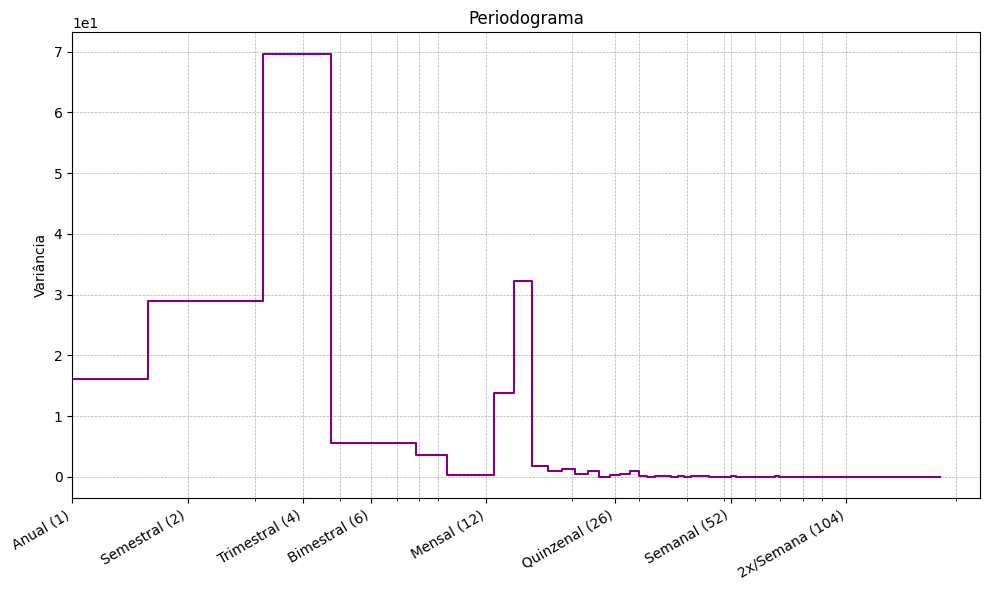

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import periodogram

def plot_periodogram(ts, detrend="linear", ax=None):
    # AQUI ESTÁ A MUDANÇA:
    # Em vez de usar pd.Timedelta("1Y"), que é ambíguo,
    # definimos a frequência de amostragem (fs) diretamente.
    # Se seus dados são diários, a frequência é ~365.25 amostras por ano.
    fs = 365.25
    
    frequencies, spectrum = periodogram(
        ts,
        fs=fs,
        detrend=detrend,
        window="boxcar",
        scaling="spectrum",
    )
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6)) # Adicionei um figsize para melhor visualização
        
    ax.step(frequencies, spectrum, color="purple")
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 4, 6, 12, 26, 52, 104])
    ax.set_xticklabels([
        "Anual (1)",
        "Semestral (2)",
        "Trimestral (4)",
        "Bimestral (6)",
        "Mensal (12)",
        "Quinzenal (26)",
        "Semanal (52)",
        "2x/Semana (104)", # Legenda um pouco mais clara
    ],
        rotation=30,
        ha="right", # Alinha o texto para não sobrepor o eixo
    )
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.set_ylabel("Variância")
    ax.set_title("Periodograma")
    ax.grid(True, which="both", linestyle='--', linewidth=0.5) # Adicionei um grid
    plt.tight_layout()
    return ax

# Agora você pode chamar a função sem erros
plot_periodogram(df_quinzenal['Volume Útil Armazenado (%)']);
plt.show() # Adicione para garantir que o gráfico seja exibido

In [26]:

# --- CONSTANTES GLOBAIS ---
TARGET = 'Volume Útil Armazenado (%)'
FORECAST_HORIZON = 6
LAG = 1
N_SPLITS = 10 # Número de janelas de validação (folds)

# --- 2. SETUP DO LOOP DE VALIDAÇÃO CRUZADA ---

# TimeSeriesSplit garante que os dados de treino sempre vêm antes dos de teste.
tscv = TimeSeriesSplit(
    n_splits=N_SPLITS,
    test_size=FORECAST_HORIZON,
    gap=0 # Sem gap entre treino e teste
)

# Listas para armazenar os resultados de cada fold
all_preds_lr = []
all_preds_hybrid = []
all_y_test = []


# --- INÍCIO DO LOOP ---
for fold, (train_idx, test_idx) in enumerate(tscv.split(df_quinzenal)):
    
    df_quinzenal_train = df_quinzenal.iloc[train_idx]
    df_quinzenal_test = df_quinzenal.iloc[test_idx]
    
    print(f"Fold {fold+1}/{N_SPLITS}")
    print(f"  - Período de Treino: {df_quinzenal_train.index.min().date()} a {df_quinzenal_train.index.max().date()}")
    print(f"  - Período de Teste:  {df_quinzenal_test.index.min().date()} a {df_quinzenal_test.index.max().date()}")

    # --- Feature Engineering para este Fold ---
    dp = DeterministicProcess(
        index=df_quinzenal_train.index,
        constant=True, order=1,
        additional_terms=[
            Fourier(period=365.25 * 2, order=1),
            CalendarFourier(freq="YE", order=2)
        ],
        drop=True
    )
    X_train_det = dp.in_sample()
    X_train_lag = pd.DataFrame({f'lag_{LAG}': df_quinzenal_train[TARGET].shift(LAG)})
    X_train = pd.concat([X_train_det, X_train_lag], axis=1)
    y_train = df_quinzenal_train[TARGET]
    X_train = X_train.dropna()
    y_train = y_train.loc[X_train.index] # Alinhar y_train com X_train
    
    # --- MODELO 1: REGRESSÃO LINEAR MULTIOUTPUT ---
    
    ### CORREÇÃO 1: Transformar o y_train em multi-step e usar MultiOutputRegressor ###
    # Isso garante que o modelo linear seja treinado corretamente para prever 30 dias.
    y_train_multi = make_multistep_target(y_train, steps=FORECAST_HORIZON)
    X_train_aligned_lr, y_train_multi_aligned = X_train.align(y_train_multi, join='inner', axis=0)
    
    model_lr_base = LinearRegression()
    model_lr = MultiOutputRegressor(model_lr_base)
    model_lr.fit(X_train_aligned_lr, y_train_multi_aligned)
    
    # Preparar features para a previsão
    X_forecast_det = dp.out_of_sample(steps=FORECAST_HORIZON)
    last_known_lag = df_quinzenal_train[TARGET].iloc[-LAG]
    X_forecast_lag = pd.DataFrame({f'lag_{LAG}': [last_known_lag] * FORECAST_HORIZON}, index=X_forecast_det.index)
    X_forecast = pd.concat([X_forecast_det, X_forecast_lag], axis=1)
    
    preds_lr = model_lr.predict(X_forecast)
    # A saída é (1, 30), pegamos a primeira linha e criamos a Série
    preds_lr = pd.Series(preds_lr[0], index=df_quinzenal_test.index)
    
    # --- MODELO 2: HÍBRIDO (TENDÊNCIA LR + RESÍDUOS XGBOOST COM DIRREC) ---
    
    # 2.1 Treinar o modelo de tendência (usando dados alinhados do X_train original)
    X_train_aligned, y_train_aligned = X_train.align(y_train, join='inner', axis=0) # Alinhar y_train 1D
    model_trend = LinearRegression()
    model_trend.fit(X_train_aligned[['trend']], y_train_aligned)

    # 2.2 Calcular os resíduos no treino
    y_train_residuals = y_train_aligned - model_trend.predict(X_train_aligned[['trend']])
    
    # 2.3 Preparar features sazonais/lag para o XGBoost
    seasonal_features = [col for col in X_train.columns if col not in ['const', 'trend']]
    X_train_seasonal = X_train_aligned[seasonal_features]

    # Transformar os resíduos 1D em um alvo 2D multi-step
    y_train_residuals_multi = make_multistep_target(y_train_residuals, steps=FORECAST_HORIZON)

    # Alinhar as features com o novo alvo multi-step para remover NaNs
    X_train_seasonal_aligned, y_train_residuals_multi_aligned = X_train_seasonal.align(
        y_train_residuals_multi, join='inner', axis=0
    )
    
    # 2.4 Treinar o modelo DirRec (RegressorChain) nos resíduos
    xgb_base_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
    model_chain = RegressorChain(xgb_base_model, random_state=42)
    model_chain.fit(X_train_seasonal_aligned, y_train_residuals_multi_aligned)
    
    # 2.5 Fazer a previsão com a cadeia
    X_forecast_seasonal = X_forecast[seasonal_features]
    
    ### CORREÇÃO 2: Adicionar a chamada .predict() que estava faltando ###
    preds_residuals = model_chain.predict(X_forecast_seasonal)
    
    # A saída é (1, 30), então pegamos a primeira linha
    preds_residuals = pd.Series(preds_residuals[0], index=df_test.index)
    
    # 2.6 Previsão final híbrida = tendência + resíduos
    preds_trend = model_trend.predict(X_forecast[['trend']])
    preds_hybrid = preds_trend + preds_residuals
    # preds_hybrid já é uma Série, não precisa recriar
    
    # --- Armazenar resultados do Fold ---
    all_preds_lr.append(preds_lr)
    all_preds_hybrid.append(preds_hybrid)
    all_y_test.append(df_test[TARGET])
    previsao_grafico(df_test[TARGET], preds_lr, preds_hybrid)

print("="*50)
print("Validação finalizada.")

# --- 3. AVALIAÇÃO FINAL ---

# Concatenar todos os resultados
final_preds_lr = pd.concat(all_preds_lr)
final_preds_hybrid = pd.concat(all_preds_hybrid)
final_y_test = pd.concat(all_y_test)


previsao_grafico(final_y_test, final_preds_lr, final_preds_hybrid)

Fold 1/10
  - Período de Treino: 2016-04-02 a 2023-04-11
  - Período de Teste:  2023-04-26 a 2023-07-10


ValueError: Length of values (6) does not match length of index (90)

In [ ]:
# Usando o DataFrame diário original 'df'

# 1. Criar a variável de estado: 1 se for risco, 0 se não for
df['estado_critico'] = (df[TARGET] <= 30).astype(int)

# 2. Criar a variável alvo: queremos usar os dados de HOJE para prever
#    o estado daqui a 90 dias.
HORIZONTE_RISCO = 90
df['risco_futuro'] = df['estado_critico'].shift(-HORIZONTE_RISCO)

# Remover os NaNs no final criados pelo shift
df_classificacao = df.dropna()

print("--- DataFrame com Alvo de Classificação ---")
# Note como 'risco_futuro' em uma data é o 'estado_critico' 90 dias depois
print(df_classificacao[[TARGET, 'estado_critico', 'risco_futuro']].head(10))

# Agora você pode treinar um modelo de CLASSIFICAÇÃO (LogisticRegression, XGBClassifier)
# Features: trend, fourier, lags do VOLUME ORIGINAL
# Alvo (Target): a coluna 'risco_futuro'